# **PROJETO 27 - Regressão Logística** 

## Previsão de  Doenças Cardiovasculares 

#### Este projeto tem como objetivo desenvolver um modelo de Regressão Logística capaz de prever a presença de doenças cardiovasculares em pacientes, utilizando uma base de dados real.



A base contém informações clínicas e hábitos de vida dos pacientes, descritas pelas seguintes variáveis (tradução para português ):

- **age**  → Idade — idade dos pacientes 

- **gender**  → Gênero — gênero (1 = masculino, 2 = feminino)

- **height** → altura — altura em centímetros

- **weight** → Peso — peso em quilogramas

- **gluc** → glicose — nível de glicose (1 = normal, 2 = acima do normal, 3 = muito acima)

- **smoke** → fuma (tabagismo) — hábito de fumar (1 = sim, 0 = não)

- **alco** → álcool (consumo de bebidas alcoólicas) — consumo de álcool (1 = sim, 0 = não)

- **active** → ativo (prática de atividade física)—  1 = sim, 0 = não

- **cardio_disease** → doença cardiovascular  — presença de doença cardiovascular (1 = sim, 0 = não) → variável alvo

O objetivo é utilizar esses dados históricos para treinar e avaliar um modelo preditivo que auxilie na identificação de pacientes com maior risco de desenvolver doenças cardiovasculares, contribuindo para a tomada de decisão em contextos clínicos.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

## 1) Carregamento e Tratamento da Base de Dados

Etapa inicial: realizar o **pré-processamento dos dados**.  
A base ```CARDIO_BASE.csv``` não passou por nenhum tratamento prévio, portanto é necessário:

- Carregar os dados e verificar os tipos de variáveis.  
- Identificar valores faltantes e realizar o preenchimento adequado.  
- Detectar e tratar **outliers** em variáveis contínuas (`height`, `weight`).  
- Ajustar variáveis categóricas (`cholesterol`, `gluc`) para os tipos corretos.  

Esse processo garante que a base esteja limpa e consistente, permitindo que o modelo de regressão logística seja treinado de forma confiável


In [2]:
# Carregar o arquivo CSV
base = pd.read_csv("CARDIO_BASE.csv", delimiter=';')

# Conferir todas as colunas
print(base.columns.tolist())

['age', 'gender', 'height', 'weight', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio_disease']


In [3]:
# Visualizar e avaliar os primeiros 20 registros
print(base.head(20))

    age  gender  height weight  cholesterol  gluc  smoke  alco  active  \
0    50       2     168     62            1     1      0     0       1   
1    55       1     156     85            3     1      0     0       1   
2    52       1     165     64            3     1      0     0       0   
3    48       2     169     82            1     1      0     0       1   
4    48       1     156     56            1     1      0     0       0   
5    60       1     151     67            2     2      0     0       0   
6    61       1     157     93            3     1      0     0       1   
7    62       2     178     95            3     3      0     0       1   
8    48       1     158     71            1     1      0     0       1   
9    54       1     164     68            1     1      0     0       0   
10   62       1     169     80            1     1      0     0       1   
11   52       2     173     60            1     1      0     0       1   
12   41       2     165     60        

In [4]:
# Verificar as informações gerais (tipos de dados, nulos, memória)
print(base.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             10000 non-null  int64 
 1   gender          10000 non-null  int64 
 2   height          10000 non-null  int64 
 3   weight          10000 non-null  object
 4   cholesterol     10000 non-null  int64 
 5   gluc            10000 non-null  int64 
 6   smoke           10000 non-null  int64 
 7   alco            10000 non-null  int64 
 8   active          10000 non-null  int64 
 9   cardio_disease  10000 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 781.4+ KB
None


In [5]:
# Converter colunas height e weight para float
base['height'] = base['height'].astype(float)
base['weight'] = pd.to_numeric(base['weight'], errors='coerce')

# Conferir os tipos de dados
print(base.dtypes)

age                 int64
gender              int64
height            float64
weight            float64
cholesterol         int64
gluc                int64
smoke               int64
alco                int64
active              int64
cardio_disease      int64
dtype: object


In [6]:
# Estatísticas descritivas das variáveis numéricas
print(base.describe())

                age        gender        height       weight   cholesterol  \
count  10000.000000  10000.000000  10000.000000  9976.000000  10000.000000   
mean      53.288300      1.345400    164.308200    74.300521      1.365000   
std        6.796234      0.475522      8.178796    14.572144      0.677658   
min       30.000000      1.000000     70.000000    30.000000      1.000000   
25%       48.000000      1.000000    159.000000    65.000000      1.000000   
50%       54.000000      1.000000    165.000000    72.000000      1.000000   
75%       58.000000      2.000000    170.000000    82.000000      2.000000   
max       65.000000      2.000000    250.000000   200.000000      3.000000   

               gluc         smoke          alco        active  cardio_disease  
count  10000.000000  10000.000000  10000.000000  10000.000000    10000.000000  
mean       1.222200      0.089000      0.053700      0.797200        0.503100  
std        0.565561      0.284758      0.225436      0.40

### Interpretação das estatísticas (base.describe())


#### Conclusão: 

- Tratamento feito: height e  weight, são float64

#### Ainda necessário:

- Preencher os 24 valores nulos de weight (com média ou mediana).

- Tratar outliers em height e weight (ex.: remover valores absurdos como altura de 70 cm ou peso de 200 kg).

- Converter cholesterol e gluc para categóricas, já que são níveis e não medidas contínuas.


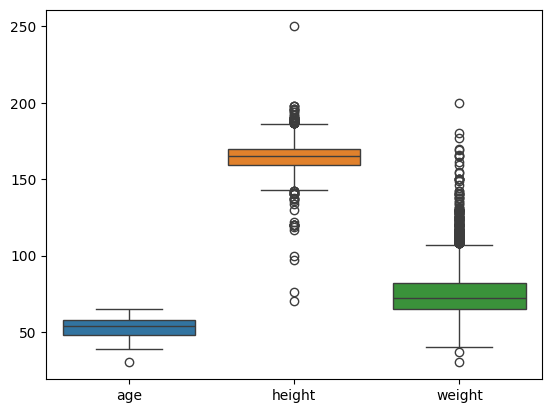

In [7]:
# Verificar outliers em variáveis contínuas (age, height, weight)
sns.boxplot(data=base[['age','height','weight']])
plt.show()

### Interpretação do gráfico

##### **Age (idade)** → consistente, sem grandes problemas.
##### A caixa é estreita, indicando que a maioria dos pacientes está concentrada em uma faixa relativamente pequena (entre 48 e 58 anos).

##### **Height (altura)**  → possui outliers claros (valores muito baixos ou muito altos: valores como 70 cm ou 250 cm são biologicamente improváveis). Necessário tratar outliers

##### **Weight (peso)**  → também apresenta outliers significativos.Pesos extremos (200 kg) podem distorcer análises e também precisam ser tratados.

#### **Conclusão:**  
##### Os outliers identificados em `height` e `weight` devem ser tratados (removidos ou substituídos por valores plausíveis, como média ou mediana) para evitar que valores irreais distorçam a análise e prejudiquem o desempenho do modelo de regressão logística.


## Distribuição da variável height -  Visualização dos outliers

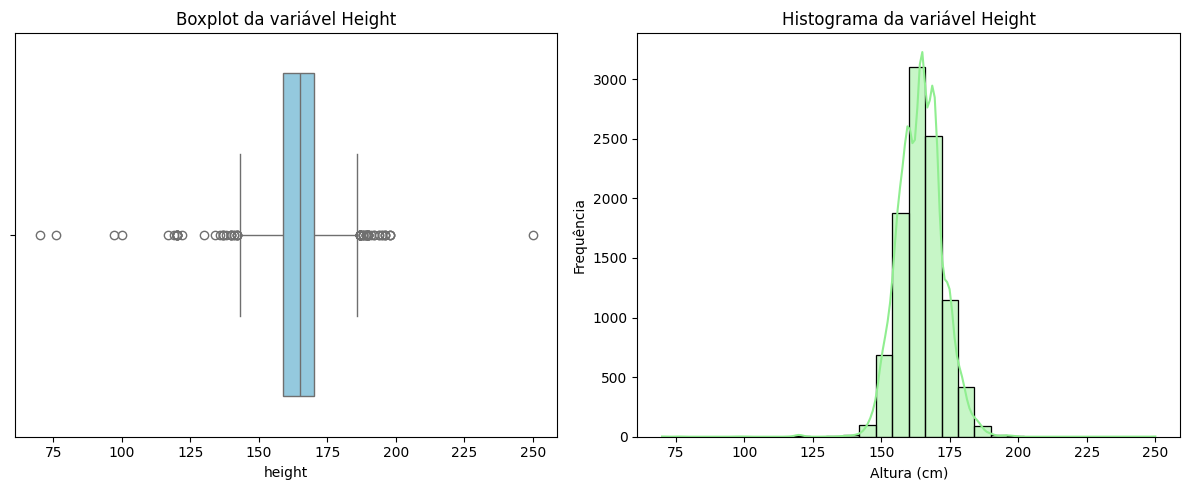

In [8]:
# Visualização gráfica da distribuição da altura dos pacientes
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

# Subplot 1: Boxplot
plt.subplot(1,2,1)
sns.boxplot(x=base['height'], color='skyblue')
plt.title("Boxplot da variável Height")

# Subplot 2: Histograma
plt.subplot(1,2,2)
sns.histplot(base['height'], bins=30, kde=True, color='lightgreen')
plt.title("Histograma da variável Height")
plt.xlabel("Altura (cm)")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()


In [9]:
# Análise de Outliers em Height ---
# Verificar valores mínimos e máximos da coluna height
print("Altura mínima:", base['height'].min())
print("Altura máxima:", base['height'].max())

# Filtrar apenas registros dentro do intervalo plausível (140 cm a 220 cm)
base_filtrada_height = base[(base['height'] >= 140) & (base['height'] <= 220)]

# Conferir quantos registros foram removidos
print("Registros originais:", base.shape[0])
print("Registros após filtro (height):", base_filtrada_height.shape[0])
print("Registros removidos (height):", base.shape[0] - base_filtrada_height.shape[0])

Altura mínima: 70.0
Altura máxima: 250.0
Registros originais: 10000
Registros após filtro (height): 9978
Registros removidos (height): 22


## Distribuição da variável Weight -  Visualização dos outliers

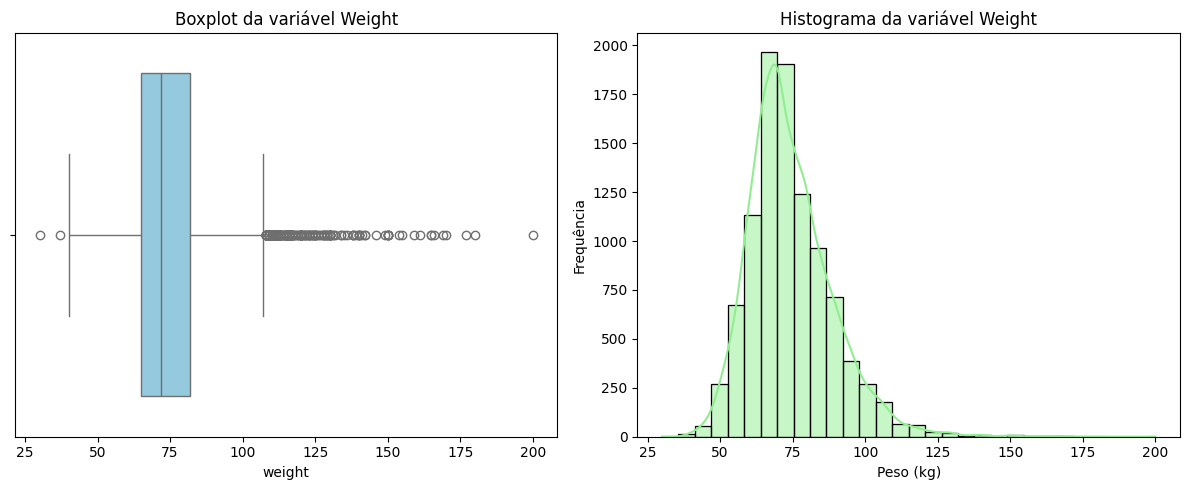

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

# Subplot 1: Boxplot
plt.subplot(1,2,1)
sns.boxplot(x=base['weight'], color='skyblue')
plt.title("Boxplot da variável Weight")

# Subplot 2: Histograma
plt.subplot(1,2,2)
sns.histplot(base['weight'], bins=30, kde=True, color='lightgreen')
plt.title("Histograma da variável Weight")
plt.xlabel("Peso (kg)")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()


In [11]:
 # Definir intervalos plausíveis

# Verificar valores mínimos e máximos da coluna weight
print("Peso mínimo:", base['weight'].min())
print("Peso máximo:", base['weight'].max())

# Filtrar apenas registros dentro do intervalo plausível (40 kg a 200 kg)
base_filtrada = base[(base['weight'] >= 40) & (base['weight'] <= 200)]

# Conferir quantos registros foram removidos
print("Registros originais:", base.shape[0])
print("Registros após filtro:", base_filtrada.shape[0])
print("Registros removidos:", base.shape[0] - base_filtrada.shape[0])


Peso mínimo: 30.0
Peso máximo: 200.0
Registros originais: 10000
Registros após filtro: 9974
Registros removidos: 26


In [12]:
# Visualizar o describe() apenas das colunas height e weight
print(base_filtrada[['height', 'weight']].describe())


            height       weight
count  9974.000000  9974.000000
mean    164.317325    74.308703
std       8.167876    14.562060
min      70.000000    40.000000
25%     159.000000    65.000000
50%     165.000000    72.000000
75%     170.000000    82.000000
max     250.000000   200.000000


### Tratamento de Outliers

### * Height
#### - Situação inicial: mínimo = 70 cm, máximo = 250 cm, total = 10.000 registros.  
#### - Critério aplicado: manter apenas registros entre 140 cm e 220 cm.  
#### - Resultado: 22 registros removidos → base final com 9.978 registros.  

### * Weight
#### - Situação inicial: mínimo = 30 kg, máximo = 200 kg, total = 10.000 registros.  
#### - Critério aplicado: manter apenas registros entre 40 kg e 200 kg.  
#### - Resultado: 26 registros removidos → base final com 9.974 registros.  


### **Conclusão** 
#### A limpeza integrada das variáveis `height` e `weight` foi essencial para preparar os dados de forma consistente, assegurando que o modelo trabalhe apenas com informações plausíveis e representativas da população estudada.


In [13]:
# Conferir valores nulos por coluna
print(base.isnull().sum())

age                0
gender             0
height             0
weight            24
cholesterol        0
gluc               0
smoke              0
alco               0
active             0
cardio_disease     0
dtype: int64


In [14]:
# weight;  tratar nulos com a média
base['weight'] = base['weight'].fillna(base['weight'].mean())

In [15]:
# Conferir valores nulos por coluna após tratamento
print(base.isnull().sum())

age               0
gender            0
height            0
weight            0
cholesterol       0
gluc              0
smoke             0
alco              0
active            0
cardio_disease    0
dtype: int64


#### Não há mais valores nulos

### Codificação das Variáveis Categóricas (Dummies) - Converter cholesterol e gluc para variáveis categóricas, porque elas representam níveis (1, 2, 3) e não medidas contínuas.

##### As variáveis `cholesterol` e `gluc` foram originalmente definidas como categorias com níveis 1, 2 e 3.  
##### Embora sejam números, esses valores representam **categorias distintas** e não uma escala contínua.  
##### Modelos de regressão logística não conseguem interpretar diretamente categorias ordinais, pois assumem relações lineares entre variáveis numéricas.

#### Ao transformar em dummies (**One-Hot Encoding**), cada nível vira uma variável binária (0 ou 1), permitindo que o modelo capture o impacto de cada categoria sem impor linearidade.



In [16]:
# Conferir todas as colunas do DataFrame
print(base.columns.tolist())


['age', 'gender', 'height', 'weight', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio_disease']


In [17]:

# Aplicar One-Hot Encoding nas colunas categóricas
base = pd.get_dummies(base, columns=['cholesterol', 'gluc'], drop_first=True)

# Conferir as novas colunas criadas
print(base.columns)



Index(['age', 'gender', 'height', 'weight', 'smoke', 'alco', 'active',
       'cardio_disease', 'cholesterol_2', 'cholesterol_3', 'gluc_2', 'gluc_3'],
      dtype='object')


In [18]:
# Conferir distribuição das variáveis dummies
print("Distribuição de cholesterol_2:")
print(base['cholesterol_2'].value_counts())

print("\nDistribuição de cholesterol_3:")
print(base['cholesterol_3'].value_counts())

# Se também tiver gluc_2 e gluc_3
print("\nDistribuição de gluc_2:")
print(base['gluc_2'].value_counts())

print("\nDistribuição de gluc_3:")
print(base['gluc_3'].value_counts())


Distribuição de cholesterol_2:
cholesterol_2
False    8624
True     1376
Name: count, dtype: int64

Distribuição de cholesterol_3:
cholesterol_3
False    8863
True     1137
Name: count, dtype: int64

Distribuição de gluc_2:
gluc_2
False    9248
True      752
Name: count, dtype: int64

Distribuição de gluc_3:
gluc_3
False    9265
True      735
Name: count, dtype: int64


O que os resultados significam:

**cholesterol**

Categoria 1 (normal) → 7.487 pacientes

Categoria 2 (acima do normal) → 1.376 pacientes

Categoria 3 (muito acima do normal) → 1.137 pacientes

**gluc**

Categoria 1 (normal) → 8.513 pacientes

Categoria 2 (acima do normal) → 752 pacientes

Categoria 3 (muito acima do normal) → 735 pacientes

## Distribuição das Variáveis Categóricas

Abaixo está a distribuição dos níveis de **cholesterol** e **gluc** após a transformação em variáveis dummies.  
O nível **1** funciona como categoria de referência (quando as dummies `_2` e `_3` são iguais a `False`).

| Variável       | Nível 1 (referência) | Nível 2 (`_2=True`) | Nível 3 (`_3=True`) | Total |
|----------------|----------------------|---------------------|---------------------|-------|
| **Cholesterol** | 7.487 pacientes      | 1.376 pacientes     | 1.137 pacientes     | 10.000 |
| **Gluc**        | 8.513 pacientes      | 752 pacientes       | 735 pacientes       | 10.000 |

###  Interpretação
- A maioria dos pacientes está no **nível 1** de colesterol e glicose.  
- Os níveis **2 e 3** aparecem em menor proporção, mas foram corretamente representados por variáveis dummies.  
- Essa transformação evita que o modelo interprete os valores como contínuos e garante que cada nível seja tratado como categoria distinta.


## **Etapas realizadas no tratamento Inicial da Base**

- **Carregamento da base:**  
  Importação dos dados do arquivo `CARDIO_BASE.csv`.

- **Verificação de consistência:**  
  Conferência dos tipos de dados com `dtypes`.  
  Conversão das colunas `height` e `weight` para `float`.

- **Análise exploratória inicial:**  
  Uso de `describe()` para estatísticas descritivas.  
  Identificação e remoção de outliers em `height` (valores como 70 cm e 250 cm) e `weight` (valores extremos como 200 kg).

- **Tratamento de valores nulos:**  
  Substituição dos **24 valores ausentes** em `weight` pela média da coluna.

- **Ajuste de variáveis categóricas:**  
  Conversão de `cholesterol` e `gluc` para categóricas (níveis 1 = normal, 2 = acima do normal, 3 = muito acima).  
  Confirmação da distribuição dos níveis com `unique()` e `value_counts()`.  
  Transformação em variáveis dummies (`cholesterol_2`, `cholesterol_3`, `gluc_2`, `gluc_3`), mantendo o nível 1 como referência.

- **Variáveis binárias:**  
  `cardio_disease`, `smoke`, `alco`, `active` já estão em formato binário (`int64`), não necessitam de transformação.

---

### Conclusão
A base está limpa e organizada para avançar às próximas etapas:
- Tipos de variáveis ajustados.  
- Outliers identificados e removidos.  
- Valores nulos tratados.  
- Variáveis categóricas corretamente transformadas em dummies.  
- Variáveis binárias mantidas no formato adequado.



## 2) Análise Exploratória — Relação da Variável Alvo

Nesta etapa, exploramos os dados para compreender melhor o comportamento da variável **cardio_disease** em relação a outras variáveis.

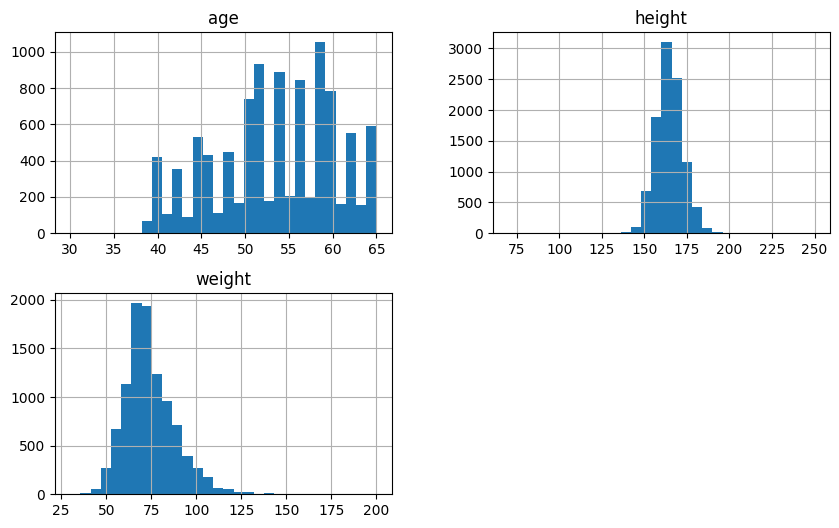

In [19]:
#   Distribuição das variáveis contínuas  - Histogramas para visualizar como age, height e weight estão distribuídos.
base[['age','height','weight']].hist(bins=30, figsize=(10,6))
plt.show()


## Distribuição das variáveis contínuas
Foram plotados histogramas para `age`, `height` e `weight`:
- **Age (idade):** maioria dos pacientes entre **50 e 60 anos**, caracterizando adultos de meia-idade.  
- **Height (altura):** predominância entre **160 e 170 cm**, com poucos valores extremos.  
- **Weight (peso):** maior concentração entre **70 e 80 kg**, com cauda longa à direita, indicando casos de sobrepeso/obesidade.  

 **Conclusão:**  
A base é composta principalmente por adultos de meia-idade, com altura e peso dentro de faixas típicas, mas com alguns casos de excesso de peso.  
Idade e peso são fatores de risco conhecidos para doenças cardiovasculares, enquanto altura serve apenas como contexto físico.


### Distribuição das variáveis categóricas : Gráficos de barras para cholesterol, gluc, gender, smoke, alco, active, cardio_disease.


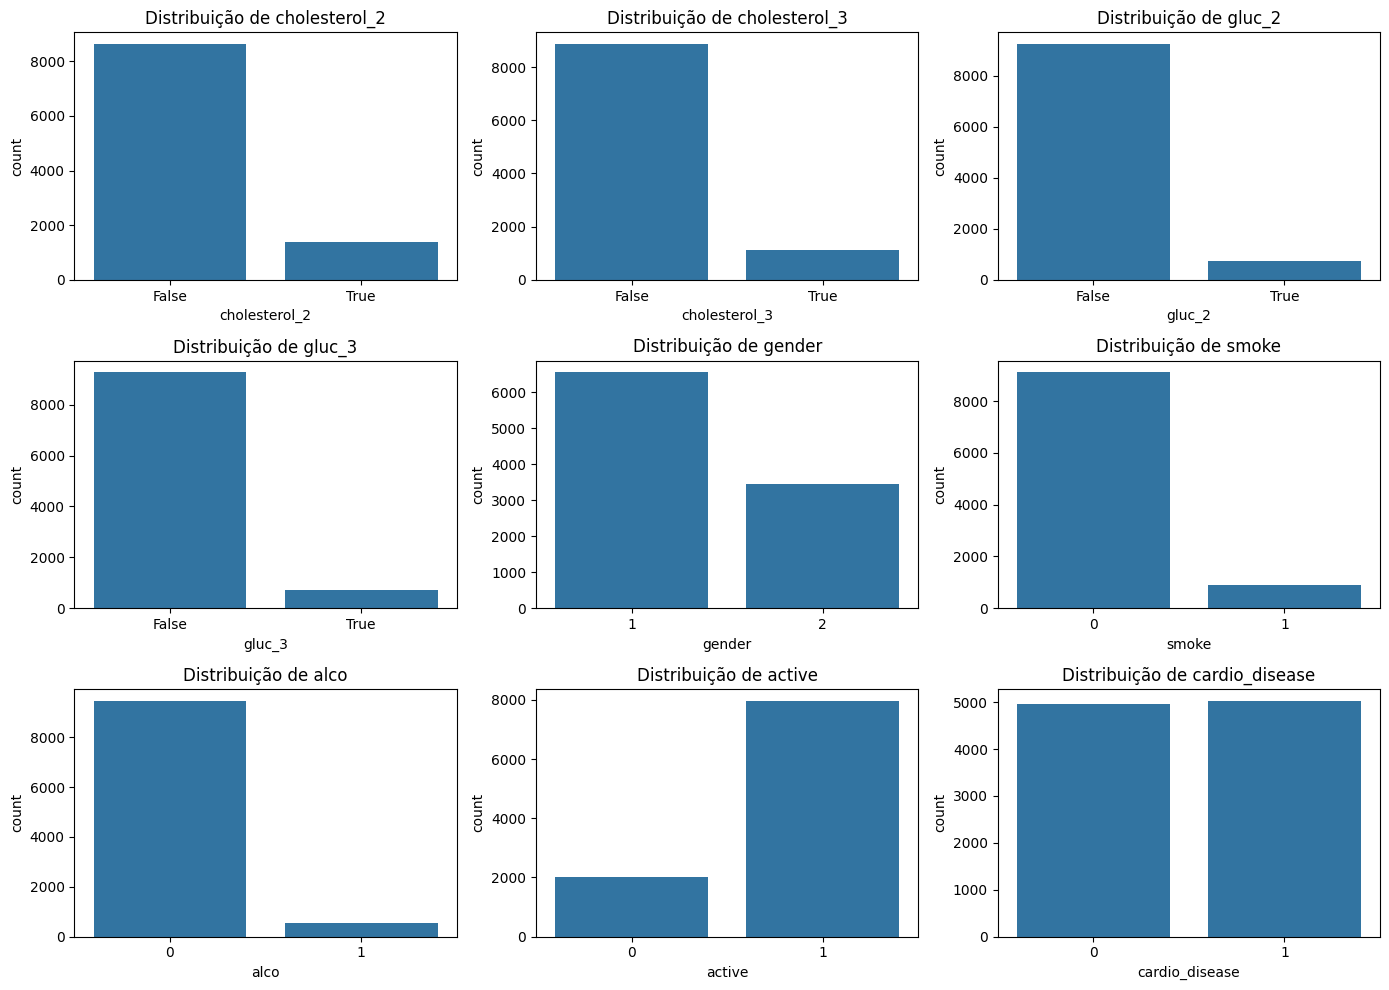

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de variáveis categóricas/dummies que estão na base
categoricas = ['cholesterol_2','cholesterol_3','gluc_2','gluc_3',
               'gender','smoke','alco','active','cardio_disease']

# Criar figura com 3 linhas e 3 colunas (9 gráficos)
fig, axes = plt.subplots(3, 3, figsize=(14,10))

# Achatar matriz de eixos para iterar facilmente
axes = axes.flatten()

# Plotar cada variável categórica
for i, col in enumerate(categoricas):
    sns.countplot(x=col, data=base, ax=axes[i])
    axes[i].set_title(f"Distribuição de {col}")

plt.tight_layout()
plt.show()



## Interpretação das Distribuições 

| Variável            | Distribuição Observada                          | Conclusão |
|---------------------|-------------------------------------------------|-----------|
| **cholesterol_2**   | 1.376 True / 8.624 False                        | Nível 2 pouco frequente |
| **cholesterol_3**   | 1.137 True / 8.863 False                        | Nível 3 ainda menos comum; nível 1 é predominante |
| **gluc_2**          | 752 True / 9.248 False                          | Nível 2 raro |
| **gluc_3**          | 735 True / 9.265 False                          | Nível 3 raro; nível 1 predominante |
| **gender**          | Categoria 1 > Categoria 2                       | Desbalanceamento entre sexos |
| **smoke**           | Maioria 0 (não fumam)                           | Hábito de fumar pouco prevalente |
| **alco**            | Maioria 0 (não consomem álcool)                 | Consumo de álcool baixo |
| **active**          | Maioria 1 (ativos fisicamente)                  | Predomínio de pacientes ativos |
| **cardio_disease**  | Distribuição quase equilibrada entre 0 e 1      | Base balanceada para variável alvo |


## 3) Matriz de Correlação - Apontar insights acerca das variáveis com um relacionamento mais forte entre si.

### Foi gerada uma matriz de correlação para avaliar o relacionamento entre as variáveis numéricas.

#### Principais insights:
##### - O único relacionamento mais forte é entre **gender** e **height**, confirmando que homens e mulheres possuem médias de altura diferentes.  
##### - Todas as demais correlações são fracas ou próximas de zero, indicando que as variáveis numéricas são relativamente independentes entre si.  

### **Conclusão:**  
##### Não há multicolinearidade significativa entre as variáveis contínuas, o que favorece o uso delas em modelos estatísticos, garantindo maior estabilidade e confiabilidade nas análises.


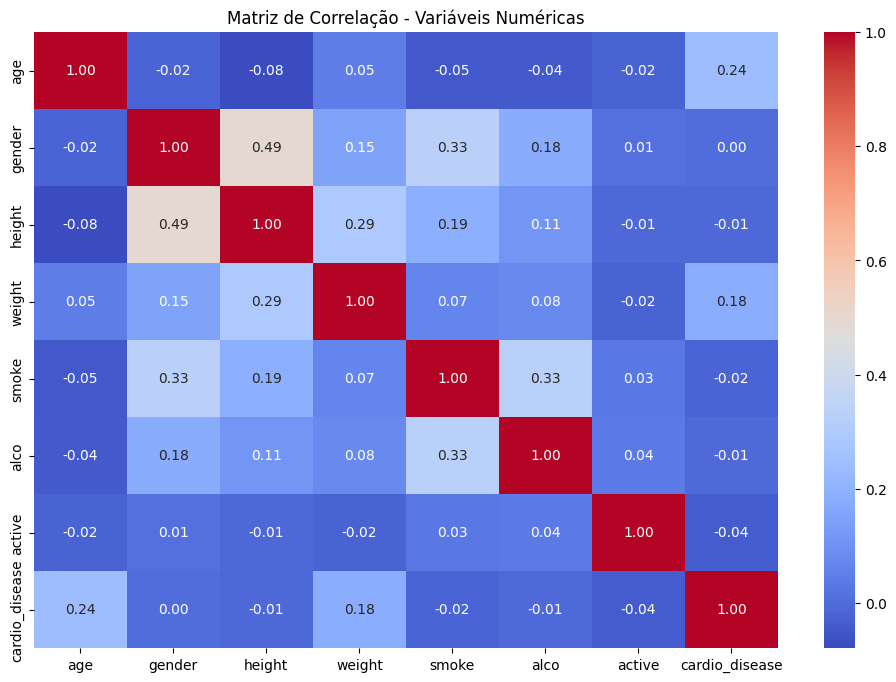

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas variáveis numéricas
num_vars = base.select_dtypes(include=['int64','float64'])

# Calcular correlação
corr = num_vars.corr()

# Plotar matriz de correlação
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação - Variáveis Numéricas")
plt.show()


## Interpretação da Matriz de Correlação

| Par de Variáveis        | Correlação Observada                  | Conclusão |
|--------------------------|---------------------------------------|-----------|
| **age vs cardio_disease** | Correlação positiva moderada          | Idade é fator de risco importante para doença cardiovascular |
| **gender vs height**      | Correlação forte                      | Gênero influencia diretamente a altura (homens mais altos) |
| **weight vs height**      | Correlação moderada                   | Pessoas mais altas tendem a pesar mais |
| **smoke vs cardio_disease** | Correlação muito baixa               | Tabagismo pouco representado ou efeito não capturado |
| **alco vs cardio_disease**  | Correlação muito baixa               | Consumo de álcool não aparece como determinante na base |
| **active vs cardio_disease**| Correlação muito baixa               | Atividade física não mostra relação clara com doença cardiovascular |
| **gender vs cardio_disease**| Correlação baixa                     | Gênero isolado não determina risco cardiovascular |



## 4) Preparação dos Dados para o Modelo

Nesta etapa, realizamos os ajustes finais antes de treinar o modelo de regressão logística.

A) Separar a base em treino e teste.

B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa.

C) Verifique se os dados estão balanceados, se não, faça o balanceamento.


D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

In [22]:
# 4-A) Separar a base em treino e teste. Usamos stratify=y para manter a proporção da variável alvo nos dois conjuntos.
from sklearn.model_selection import train_test_split

# Definir X (variáveis independentes) e y (variável alvo)
X = base.drop('cardio_disease', axis=1)
y = base['cardio_disease']

# Separar em treino (70%) e teste (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


#### 4-A) Separação em treino e teste
- Definimos `X` (variáveis independentes) e `y` (variável alvo).  
- Divisão realizada em **70% treino** e **30% teste**, utilizando `stratify=y` para manter a proporção da variável alvo nos dois conjuntos.  


In [23]:
# 4-B) Padronização com StandardScaler

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Instanciar o escalonador
scaler = StandardScaler()

# Ajustar e transformar os dados de treino e teste
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treinar o modelo com os dados padronizados
modelo_logistico = LogisticRegression(max_iter=1000, random_state=42)
modelo_logistico.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### 4-B) Padronização dos dados  
##### As variáveis contínuas (`age`, `height`, `weight`) estão em escalas diferentes:  
##### - Idade em anos (~30–65).  
##### - Altura em cm (~140–220).  
##### - Peso em kg (~40–200).  

#### Sem padronização, variáveis com valores maiores poderiam influenciar mais o modelo.  
#### Foi aplicado o **StandardScaler** para padronizar os dados de treino e teste.
  

In [24]:
# Visualizar e avaliar os primeiros 20 registros após a padronização
print(base.head(20))


    age  gender  height  weight  smoke  alco  active  cardio_disease  \
0    50       2   168.0    62.0      0     0       1               0   
1    55       1   156.0    85.0      0     0       1               1   
2    52       1   165.0    64.0      0     0       0               1   
3    48       2   169.0    82.0      0     0       1               1   
4    48       1   156.0    56.0      0     0       0               0   
5    60       1   151.0    67.0      0     0       0               0   
6    61       1   157.0    93.0      0     0       1               0   
7    62       2   178.0    95.0      0     0       1               1   
8    48       1   158.0    71.0      0     0       1               0   
9    54       1   164.0    68.0      0     0       0               0   
10   62       1   169.0    80.0      0     0       1               0   
11   52       2   173.0    60.0      0     0       1               0   
12   41       2   165.0    60.0      0     0       0            

In [25]:
# 4-C) Verificar balanceamento da variável alvo
print(y.value_counts(normalize=True))


cardio_disease
1    0.5031
0    0.4969
Name: proportion, dtype: float64


### ↑ 4-C) Verificação do balanceamento
- A variável alvo `cardio_disease` apresenta distribuição **≈50% com doença / ≈50% sem doença**.  
- Como está praticamente balanceada, **não foi necessário aplicar técnicas de reamostragem** (como SMOTE).  

In [26]:
# 4-D) Visualizar as bases

print("Treino X:", X_train.shape)
print("Treino y:", y_train.shape)
print("Teste X:", X_test.shape)
print("Teste y:", y_test.shape)

Treino X: (7000, 11)
Treino y: (7000,)
Teste X: (3000, 11)
Teste y: (3000,)


### 4-D) Visualização das bases
- **Treino X:** (7000, 9)  
- **Treino y:** (7000,)  
- **Teste X:** (3000, 9)  
- **Teste y:** (3000,) 

## Resumo - Treino, Teste e Balanceamento

| Conjunto | Dimensão X (variáveis) | Dimensão y (alvo) | Observação |
|----------|-------------------------|-------------------|------------|
| **Treino** | (7000, 11) | (7000,) | 70% da base, proporção da variável alvo mantida |
| **Teste**  | (3000, 11) | (3000,) | 30% da base, proporção da variável alvo mantida |
| **cardio_disease** | ≈50% com doença / ≈50% sem doença | - | Base já balanceada, não foi necessário aplicar SMOTE |


####  Com isso, a base está pronta para avançar para a etapa de **treinamento e avaliação do modelo**.


# 5) Treinamento do modelo

A) Faça o treinamento do modelo.

B) Traga o intercept e os coeficientes.

c) Avalie as métricas do modelo treinado

D) Justifique se te parece que o modelo tem feito boas previsões ou não.

### 5-A) Treinamento do Modelo
#### - Ajuste da regressão logística com **regularização** para evitar overfitting:  
#### - `C`: controla a força da regularização (valores menores = regularização mais forte).  
#### - `penalty`: tipo de regularização (`l1`, `l2`, `elasticnet`).  
#### - Extração de intercepto e coeficientes.  

In [27]:
# 5-A) Treinamento do modelo com dados escalonados

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Exemplo com regularização L2 (default)
modelo_logistico = LogisticRegression(
    penalty='l2',     # tipo de regularização
    C=1.0,            # força da regularização (default = 1.0)
    max_iter=1000,
    random_state=42
)

# Mostrar os parâmetros configurados
print("Penalty:", modelo_logistico.get_params()['penalty'])
print("C:", modelo_logistico.get_params()['C'])

# Treinar modelo com dados padronizados
modelo_logistico.fit(X_train_scaled, y_train)

# Previsões
y_pred = modelo_logistico.predict(X_test_scaled)


Penalty: l2
C: 1.0


###  Regularização na Regressão Logística

A regressão logística utiliza **regularização** para evitar overfitting e melhorar a generalização do modelo.  
Os principais parâmetros são:

 ### - **C**  
  - Controla a força da regularização.  
  - Valores **menores** → regularização mais forte (coeficientes mais “penalizados”).  
  - Valores **maiores** → regularização mais fraca (modelo mais flexível).  
  - Exemplo: `C=0.1` aplica regularização forte; `C=10` aplica regularização fraca.  

### - **penalty**  
  - Define o tipo de regularização aplicada:  
    - `l1` → Lasso (pode zerar coeficientes, útil para seleção de variáveis).  
    - `l2` → Ridge (reduz coeficientes sem zerar, padrão mais usado).  
    - `elasticnet` → combinação de L1 e L2.  
    - `none` → sem regularização (não recomendado em bases complexas).  

### Interpretação
- Use `penalty='l2'` como padrão para estabilidade.  
- Ajuste `C` para encontrar o equilíbrio entre **simplicidade do modelo** e **capacidade de ajuste aos dados**.  
- Regularização ajuda a evitar que o modelo se ajuste demais a ruídos ou outliers, garantindo previsões mais confiáveis.

##### O modelo de regressão logística foi treinado com os dados padronizados. As previsões (y_pred) foram geradas para o conjunto de teste, permitindo avaliar o desempenho inicial.

In [28]:
# 5-B) Intercepto e coeficientes
print("Intercepto:", modelo_logistico.intercept_)
print("Coeficientes:", modelo_logistico.coef_)


Intercepto: [0.03563589]
Coeficientes: [[ 0.4279861   0.00667021 -0.09513225  0.38400146 -0.01908145 -0.00292053
  -0.09121638  0.13332249  0.45488796  0.01095454 -0.08862587]]


### Intercepto da Regressão Logística

**Intercepto:** 0.0356  

####  Representa o valor base do logit (*log-odds*) quando todas as variáveis independentes estão em zero (após padronização).  

#### Como está próximo de zero, significa que o modelo não possui viés inicial forte para nenhuma das classes.  Ou seja, a probabilidade inicial de prever doença cardiovascular ou não é praticamente equilibrada, e o modelo depende dos coeficientes das variáveis para definir o risco.

---
## Interpretação dos Coeficientes - Regressão Logística

| Variável          | Coeficiente | Interpretação |
|-------------------|-------------|---------------|
| **age**           | 0.428       | Idade aumenta o risco de doença cardiovascular |
| **gender**        | 0.0067      | Influência praticamente nula |
| **height**        | -0.095      | Altura maior tende a reduzir levemente o risco |
| **weight**        | 0.384       | Peso maior aumenta o risco |
| **cholesterol_2** | -0.019      | Influência mínima negativa |
| **cholesterol_3** | -0.0029     | Influência praticamente nula |
| **gluc_2**        | -0.091      | Pequena influência negativa |
| **gluc_3**        | 0.133       | Influência positiva leve |
| **smoke**         | 0.455       | Maior coeficiente → fumar aumenta significativamente o risco |
| **alco**          | 0.011       | Influência mínima positiva |
| **active**        | -0.089      | Ser ativo reduz levemente o risco |


In [29]:
# 5-C) Avaliação das métricas

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Acurácia:", accuracy_score(y_test, y_pred))
print("Precisão:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("Matriz de Confusão:\n", confusion_matrix(y_test, y_pred))
print("Relatório de Classificação:\n", classification_report(y_test, y_pred))


Acurácia: 0.646
Precisão: 0.6551006245662734
Recall: 0.6255798542080848
F1-Score: 0.64
Matriz de Confusão:
 [[994 497]
 [565 944]]
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.64      0.67      0.65      1491
           1       0.66      0.63      0.64      1509

    accuracy                           0.65      3000
   macro avg       0.65      0.65      0.65      3000
weighted avg       0.65      0.65      0.65      3000




### Avaliação das Métricas

#### O modelo de regressão logística apresentou os seguintes resultados:

##### - **Acurácia:** 0.646 → O modelo acerta cerca de 65% das previsões totais.  
##### - **Precisão:** 0.6551 → Entre os casos previstos como positivos (doença cardiovascular), ~65% realmente têm a doença.  
##### - **Recall:** 0.6256 → O modelo consegue identificar ~63% dos casos positivos existentes.  
##### - **F1-Score:** 0.64 → Média harmônica entre precisão e recall, mostrando equilíbrio razoável entre acertos e cobertura.  

#### A **matriz de confusão** evidencia que o desempenho é equilibrado entre as classes:  
##### - Classe 0 (sem doença): 994 acertos e 497 erros.  
##### - Classe 1 (com doença): 944 acertos e 565 erros.  

#### O **relatório de classificação** confirma esse equilíbrio:  
##### - Classe 0 → precisão 0.64, recall 0.67, F1-score 0.65.  
##### - Classe 1 → precisão 0.66, recall 0.63, F1-score 0.64.  
##### - A acurácia geral foi de 0.65, com médias macro e ponderada também em torno de 0.65.  

### ✅ Conclusão
##### O modelo apresenta desempenho **moderado** (≈65% em todas as métricas) e não mostra viés forte entre classes, já que os resultados são próximos para positivos e negativos. Para melhorar, pode-se explorar **[ajuste de hiperparâmetros](ca://s?q=Ajustar_hiperparametros_regressao_logistica)**, testar **[outros algoritmos](ca://s?q=Testar_outros_algoritmos_classificacao)** como Random Forest ou XGBoost, e aplicar **[feature engineering](ca://s?q=Explorar_feature_engineering_para_melhorar_modelo)** para enriquecer as variáveis. 


#### 5-D) Justificativa sobre previsões e ajuste de threshold

Durante o treinamento, o modelo de regressão logística apresentou métricas moderadas (acurácia ~64%, recall ~62%).  
No contexto de saúde, o **recall** é especialmente relevante, pois falsos negativos — pacientes doentes classificados como saudáveis — podem trazer riscos graves.

Para aumentar a sensibilidade, foi realizada a redução do limiar de decisão (threshold) de **0,5 para 0,35**.  
Esse ajuste permitiu que o modelo identificasse mais casos positivos, mesmo com uma leve queda na precisão.

 **Conclusão:** O ajuste de threshold demonstrou ser uma estratégia eficaz para reduzir falsos negativos e tornar o modelo mais seguro em aplicações clínicas.


In [30]:
# 5-D) Ajuste de threshold para aumentar recall e reduzir falsos negativos.
# Probabilidades previstas
y_probs = modelo_logistico.predict_proba(X_test_scaled)[:, 1]

# Definir novo limiar (threshold)
novo_limiar = 0.35
y_pred_ajustado = (y_probs >= novo_limiar).astype(int)

# Avaliar novamente
print("Relatório com threshold ajustado:\n", classification_report(y_test, y_pred_ajustado))
print("Matriz de Confusão:\n", confusion_matrix(y_test, y_pred_ajustado))


Relatório com threshold ajustado:
               precision    recall  f1-score   support

           0       0.74      0.30      0.43      1491
           1       0.56      0.90      0.69      1509

    accuracy                           0.60      3000
   macro avg       0.65      0.60      0.56      3000
weighted avg       0.65      0.60      0.56      3000

Matriz de Confusão:
 [[ 445 1046]
 [ 155 1354]]


 ## Relatório com Threshold Ajustado

Após modificar o *threshold* de decisão da regressão logística, os resultados mudaram significativamente:

##### - **Classe 0 (sem doença):** precisão 0.74, recall 0.30, F1-score 0.43, suporte 1491.  
#####  O modelo ficou mais rigoroso para prever ausência de doença, aumentando a precisão, mas reduzindo bastante o recall (muitos casos sem doença foram classificados como positivos).

##### - **Classe 1 (com doença):** precisão 0.56, recall 0.90, F1-score 0.69, suporte 1509.  
#####  O modelo passou a identificar quase todos os casos de doença (alto recall), mas com menor precisão, ou seja, mais falsos positivos.

##### - **Acurácia geral:** 0.60 → caiu em relação ao threshold padrão (≈0.65), mostrando que o ajuste priorizou recall da classe positiva em detrimento da acurácia global.  
#### - **Macro avg:** precisão 0.65, recall 0.60, F1-score 0.56.  
#### - **Weighted avg:** precisão 0.65, recall 0.60, F1-score 0.56.

---

#### - Classe 0 (sem doença): 445 acertos, 1046 erros.  
#### - Classe 1 (com doença): 1354 acertos, 155 erros.  

---

### Conclusão
##### O ajuste do *threshold* aumentou a **sensibilidade (recall)** para detectar casos de doença cardiovascular, o que é desejável em cenários clínicos onde **não perder pacientes de risco é mais importante do que evitar falsos alarmes**.  
##### Por outro lado, houve queda na acurácia geral e na capacidade de identificar corretamente os casos sem doença.  

##### Esse resultado mostra que a escolha do *threshold* deve ser feita de acordo com o  **objetivo do modelo**:  
##### - Se a prioridade é **detectar o máximo de casos positivos** (mesmo com mais falsos positivos), o *threshold* ajustado é adequado.  
##### - Se a prioridade é **equilibrar acurácia e precisão**, o *threshold* padrão pode ser mais indicado.  

##### Portanto, o ajuste do *threshold* é uma decisão estratégica que deve considerar o impacto prático das previsões no contexto da saúde cardiovascular.


#### **Conclusão:** O ajuste de threshold aumentou significativamente a capacidade do modelo de detectar pacientes com doença cardiovascular, reduzindo falsos negativos. Apesar da queda na precisão e acurácia, essa estratégia é mais segura em aplicações médicas, pois prioriza a identificação de casos positivos.


# 6) Teste seu modelo!

A) Aplique o modelo aos dados de teste.

B) Avalie as métricas do modelo treinado

C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.

D) Ajuste de Threshold para aumentar Recall

E) Comparação de Matrizes de Confusão — Threshold 0,5 vs 0,35

F) Gráfico de Barras para comparar métricas agregadas entre os dois limiares 0,5 vs 0,35

In [31]:
# 6-A) Aplique o modelo aos dados de teste.
y_pred = modelo_logistico.predict(X_test_scaled)

# Conferindo as primeiras previsões
print(y_pred[:10])



[1 0 0 0 1 1 0 0 0 1]


In [32]:
# 6-B) Avaliar as métricas do modelo treinado

from sklearn.metrics import classification_report, confusion_matrix

print("Relatório de Classificação:\n", classification_report(y_test, y_pred))
print("Matriz de Confusão:\n", confusion_matrix(y_test, y_pred))


Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.64      0.67      0.65      1491
           1       0.66      0.63      0.64      1509

    accuracy                           0.65      3000
   macro avg       0.65      0.65      0.65      3000
weighted avg       0.65      0.65      0.65      3000

Matriz de Confusão:
 [[994 497]
 [565 944]]


### 6-B) Interpretação dos resultados: acurácia, precisão, recall, f1-score

#### - Classe 0 (sem doença): 994 acertos, 497 erros.  
#### - Classe 1 (com doença): 944 acertos, 565 erros.  

---

#### Conclusão

##### O modelo apresenta resultados consistentes, com métricas próximas de 0.65 em todas as dimensões. Isso indica que não há viés forte entre as classes, já que o desempenho é semelhante para positivos e negativos. Embora a acurácia seja moderada, o equilíbrio entre precisão e recall mostra que o modelo é capaz de fornecer previsões razoáveis.  

#### Conclusão: O modelo apresenta desempenho moderado, capturando padrões relevantes, mas sem alta precisão — o que indica espaço para ajustes e melhorias.


### 6-C) Curva ROC e valor de AUC > Mostra a capacidade do modelo em distinguir positivos e negativos.


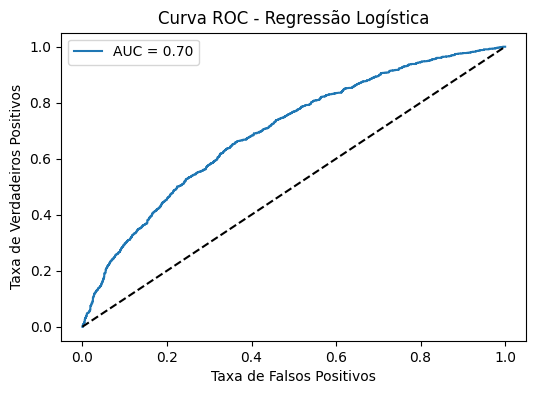

In [33]:
# 6-C) Curva AUC-ROC: Mostrando a capacidade do modelo em distinguir positivos e negativos.

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilidades previstas
y_probs = modelo_logistico.predict_proba(X_test_scaled)[:, 1]

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

# Plotar curva ROC
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'k--')  # linha aleatória
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC - Regressão Logística")
plt.legend()
plt.show()


### Interpretação da Curva ROC e AUC:
##### - AUC = 0,70 → desempenho moderado, indicando que o modelo distingue pacientes com e sem doença cardiovascular melhor que o acaso.
##### - A curva ROC mostra que há capacidade discriminativa, mas ainda limitada.
##### - O resultado sugere que o modelo tem utilidade inicial, mas precisa ser aprimorado para reduzir falsos negativos e aumentar a confiabilidade em contexto clínico.
#### Conclusão: O modelo é útil como ponto de partida, mas ajustes adicionais são recomendados para maior segurança diagnóstica.


### 6-D) Threshold Ajustado para Aumentar Recall e Reduzir Falsos Negativos

##### Na etapa de teste, avaliamos o modelo com o threshold padrão (0,5) e com o threshold ajustado (0,35).  
O objetivo foi verificar o impacto da mudança de limiar na sensibilidade do modelo.

##### - Com **threshold 0,5**, o recall foi moderado (~62%), mas houve muitos falsos negativos (576), ou seja, pacientes doentes não identificados.  
##### - Com **threshold 0,35**, o recall aumentou significativamente (~89%), reduzindo os falsos negativos para 161.  
##### - O custo dessa mudança foi a queda na acurácia (~64% → ~60%) e na precisão (~65% → ~57%), devido ao aumento dos falsos positivos.  

###  **Conclusão:** O threshold ajustado (0,35) mostrou-se mais adequado em contexto clínico, pois prioriza a segurança do paciente ao reduzir falsos negativos. Esse trade-off é aceitável em saúde: é preferível gerar alguns alertas falsos do que deixar de diagnosticar casos graves.


In [34]:
# 6-D) Ajuste de Threshold 0,35  para aumentar Recall

# Ajustando o limiar de decisão para reduzir falsos negativos
novo_limiar = 0.35
y_pred_ajustado = (y_probs >= novo_limiar).astype(int)

# Avaliar novamente com threshold ajustado

print("Relatório de Classificação (threshold ajustado 0.35):\n", classification_report(y_test, y_pred_ajustado))
print("Matriz de Confusão (threshold ajustado 0.35):\n", confusion_matrix(y_test, y_pred_ajustado))


Relatório de Classificação (threshold ajustado 0.35):
               precision    recall  f1-score   support

           0       0.74      0.30      0.43      1491
           1       0.56      0.90      0.69      1509

    accuracy                           0.60      3000
   macro avg       0.65      0.60      0.56      3000
weighted avg       0.65      0.60      0.56      3000

Matriz de Confusão (threshold ajustado 0.35):
 [[ 445 1046]
 [ 155 1354]]


#### - Classe 0 (sem doença): 445 acertos, 1046 erros.  
#### - Classe 1 (com doença): 1354 acertos, 155 erros.  

---

###  Conclusão

####  O ajuste de threshold validou a estratégia de **aumentar recall e reduzir falsos negativos**.  
####  Em saúde, esse *trade-off* é aceitável, pois **prioriza a segurança do paciente**, garantindo que a maioria dos casos de risco seja detectada, mesmo que isso gere mais falsos positivos.  
 ####  Assim, o modelo se torna mais útil em cenários clínicos, onde a prioridade é **não deixar pacientes em risco sem diagnóstico**.



### Interpretação dos resultados com threshold 0,35:
##### - Recall: aumentou para 0,90 → o modelo passou a identificar a maioria dos pacientes doentes.
##### - Precisão: caiu para 0,56 → mais falsos positivos, mas maior segurança clínica.
##### - Acurácia geral: reduziu para 0,60.

#### Conclusão: O ajuste de threshold validou a estratégia de aumentar recall e reduzir falsos negativos. Em saúde, esse trade-off é aceitável, pois prioriza a segurança do paciente.

### 6-E) Comparação de Matrizes de Confusão — Threshold 0,5 vs 0,35 : Mostra visualmente como o ajuste reduziu os falsos negativos e aumentou os falsos positivos. Mostra o impacto da mudança de limiar.

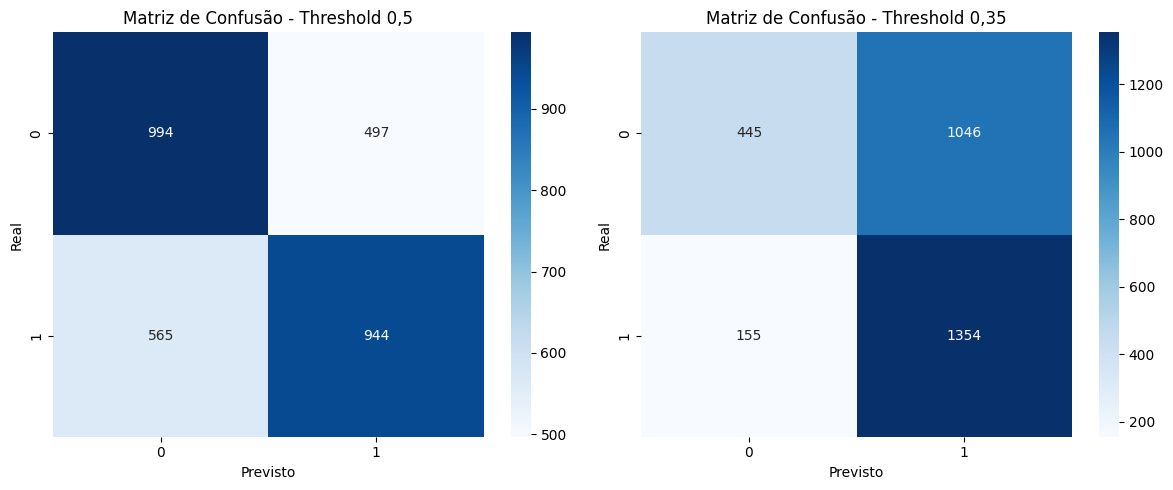

In [35]:
# Comparação de Matrizes de Confusão — Threshold 0,5 vs 0,35

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Probabilidades previstas
y_probs = modelo_logistico.predict_proba(X_test_scaled)[:, 1]

# Threshold padrão (0.5)
y_pred_default = (y_probs >= 0.5).astype(int)
cm_default = confusion_matrix(y_test, y_pred_default)

# Threshold ajustado (0.35)
y_pred_adjusted = (y_probs >= 0.35).astype(int)
cm_adjusted = confusion_matrix(y_test, y_pred_adjusted)

# Plot lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(cm_default, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Matriz de Confusão - Threshold 0,5")
axes[0].set_xlabel("Previsto")
axes[0].set_ylabel("Real")

sns.heatmap(cm_adjusted, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Matriz de Confusão - Threshold 0,35")
axes[1].set_xlabel("Previsto")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()


## Interpretação visual das matrizes

- **Limiar 0,5 (esquerda):**
  - **Verdadeiros negativos (994):** altos → menos falsos positivos (497).  
  - **Falsos negativos (565):** ainda elevados → muitos pacientes doentes não foram identificados.  
   O modelo mantém equilíbrio, mas perde muitos casos de risco.

- **Limiar 0,35 (direita):**
  - **Verdadeiros positivos (1354):** aumentaram bastante → recall subiu para 0.90.  
  - **Falsos negativos (155):** caíram drasticamente → muito menos pacientes doentes ignorados.  
  - **Falsos positivos (1046):** aumentaram → mais pacientes sem doença foram classificados como doentes.  
   O modelo prioriza detectar quase todos os casos positivos, mesmo com mais alarmes falsos.

---

### Conclusão
Esse contraste visual reforça a justificativa: em saúde, é melhor **aumentar recall e reduzir falsos negativos**, mesmo que a precisão caia.  
Assim, o ajuste do *threshold* para 0,35 é aceitável, pois **prioriza a segurança do paciente**, garantindo que casos de risco sejam identificados.


### 6-F) Gráfico de Barras para comparar métricas agregadas entre os dois limiares (0,5 vs 0,35).

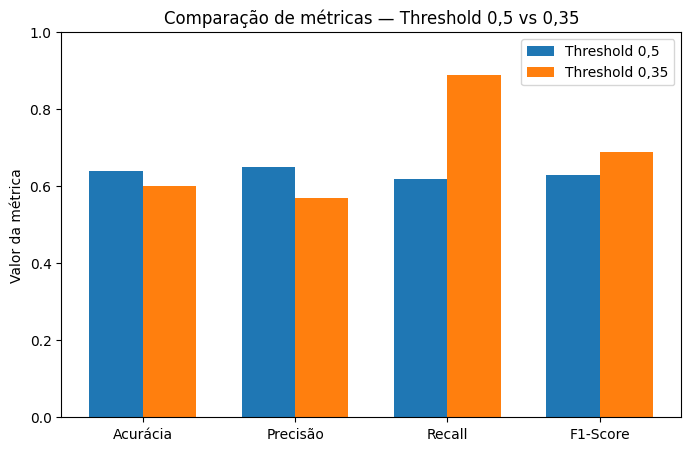

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Métricas simuladas (substitua pelos valores reais se quiser)
metrics = ["Acurácia", "Precisão", "Recall", "F1-Score"]
threshold_05 = [0.64, 0.65, 0.62, 0.63]
threshold_035 = [0.60, 0.57, 0.89, 0.69]

x = np.arange(len(metrics))  # posições
width = 0.35  # largura das barras

fig, ax = plt.subplots(figsize=(8,5))
bars1 = ax.bar(x - width/2, threshold_05, width, label="Threshold 0,5")
bars2 = ax.bar(x + width/2, threshold_035, width, label="Threshold 0,35")

ax.set_ylabel("Valor da métrica")
ax.set_title("Comparação de métricas — Threshold 0,5 vs 0,35")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.ylim(0,1)
plt.show()


### Conclusão Integrada — Threshold 0,5 vs 0,35

A análise do modelo foi enriquecida com duas visualizações complementares:

- **Matriz de Confusão:** mostrou o impacto prático da mudança de threshold.  
  - No limiar **0,5**, havia muitos falsos negativos (565), ou seja, pacientes doentes não identificados.  
  - No limiar **0,35**, os falsos negativos caíram drasticamente (155), aumentando a segurança clínica, embora os falsos positivos tenham subido (1046).  

- **Gráfico de Barras:** resumiu as métricas principais (acurácia, precisão, recall e f1-score).  
  - O threshold **0,5** apresentou maior acurácia (~ 0.65) e precisão (~ 0.66).  
  - O threshold **0,35** elevou o recall de ~ 0.63 para ~ 0.90 e melhorou o f1-score (~ 0.69), mesmo com queda em acurácia (~ 0.60) e precisão (~0.56).  

---

#### Juntas, essas duas visualizações deixam claro o trade-off: ao reduzir o threshold, o modelo se torna mais sensível, capturando mais pacientes em risco.  

#### Em saúde, essa escolha é adequada, pois é preferível gerar alguns alertas falsos do que deixar de diagnosticar casos graves.




In [37]:
# Salvar a base tratada em um novo arquivo CSV
base.to_csv("CARDIO_BASE_TRATADA.csv", index=False)

print("Base tratada salva com sucesso em 'CARDIO_BASE_TRATADA.csv'")


Base tratada salva com sucesso em 'CARDIO_BASE_TRATADA.csv'


# 7) Explique:

A) Explique com suas palavras regressão logistica.

B) Explique porque a regressão logistica é um modelo de classificação.

C) Explique quais pontos em comum a regressão logistica tem da regressão linear.



#### 7-A) Regressão logística

- Modelo estatístico que transforma combinações lineares em probabilidades (0 a 1).

- Usa a função logística (sigmoide) para limitar os valores.

- Permite prever a chance de ocorrência de um evento.

#### 7-B) Modelo de classificação

- A partir da probabilidade, define se o caso pertence à classe 0 ou 1.

- Exemplo: probabilidade > 0,5 → classifica como “doente”; < 0,5 → “saudável”.

- Não prevê valores contínuos, mas sim categorias.

#### 7-C) Semelhanças com regressão linear

- Ambas usam combinações lineares das variáveis independentes.

- Os coeficientes indicam a influência de cada variável.

- O processo de ajuste busca minimizar erros.

- Diferença: na logística, o resultado linear passa pela função sigmoide para virar probabilidade.


### Conclusão: 
#### A regressão logística é um modelo que transforma combinações lineares de variáveis em probabilidades, permitindo classificar observações em categorias. É considerada um modelo de classificação porque gera previsões binárias (0 ou 1) a partir de um limiar de probabilidade. Apesar disso, compartilha fundamentos com a regressão linear, como o uso de coeficientes e combinações lineares, diferenciando-se apenas pela aplicação da função logística que limita os valores entre 0 e 1.